In [31]:
%load_ext autoreload
%autoreload 2
%pdb on

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Automatic pdb calling has been turned ON


In [32]:
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from camels_tools import analyze_halos,load_snapshot,plot_theory_predictions
from camels_tools import from_file
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os
from glob import glob
ROOT_PATH = os.getcwd() + '/../'

In [34]:
M_star_cen = np.geomspace(1e9,1e11,num = 13)
all_results_all_b = []
all_bmin = [0.1,0.12,0.15]
for nnn in ['090','088','086','084','082']:
    filepaths = glob(os.path.join(ROOT_PATH,'data_products','camels_data','20250414',f'*snap{nnn}_haloDM.csv'))
    for filepath in filepaths:    
        num_halos = 40
        M_200_min = 0
        M_200_max = np.inf
        sfr_min = 0.1
        sfr_max = 100.0
        sim_df = load_snapshot(filepath)
        print('Input:',filepath)
        for b_min,color in zip(all_bmin,cm.inferno(np.linspace(0, 0.5, len(all_bmin)))):
            out_path = os.path.join(ROOT_PATH,'data_products','camels_stack',os.path.split(filepath)[-1][:-4] + f'_b={b_min:.2f}.h5')
            results = analyze_halos(
                filepath = filepath,
                df = sim_df,
                num_halos=num_halos,
                b_min=b_min,
                b_max=0.2,
                M_200_min=M_200_min,
                M_200_max=M_200_max,
                M_star_range = M_star_cen,
                width_factor = 2,
                sfr_min=sfr_min,
                sfr_max=sfr_max,
                out_file=out_path
            )
            print('Output:',out_path)

Input: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_data/20250414/Astrid_1P_3_0_snap090_haloDM.csv
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap090_haloDM_b=0.10.h5
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap090_haloDM_b=0.12.h5
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap090_haloDM_b=0.15.h5
Input: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_data/20250414/SIMBA_1P_3_0_snap090_haloDM.csv
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap090_haloDM_b=0.10.h5
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap090_haloDM_b=0.12.h5
Output: /Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap090_haloDM_b=0.15.h5
Input: /Us

In [22]:
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df)
df = _df[keep]


In [45]:
import camels_tools
import pandas as pd

ROOT_PATH

import dmh_tools
importlib.reload(camels_tools)
%matplotlib ipympl

In [ ]:
camels_tools.

M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
Still needs M* measurement: Index(['FRB20201124A', 'FRB20220912A', 'FRB20220725A', 'FRB20230526A',
       'FRB20230708A', 'FRB20231226A', 'FRB20240210A', 'FRB20230222B',
       'FRB20230311A', 'FRB20230926A', 'FRB20231011A', 'FRB20231123A',
       'FRB20231128A', 'FRB20231201A', 'FRB20231223C', 'FRB20231229A',
       'FRB20231230A'],
      dtype='object', name='name')
M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
M_200_range
M_star_bins
b_range
num_sampled_sightlines
sfr_range
weighted_mean
weighted_std
Still needs M* measurement: Index(['FRB20201124A', 'FRB20220912A', 'FRB202207

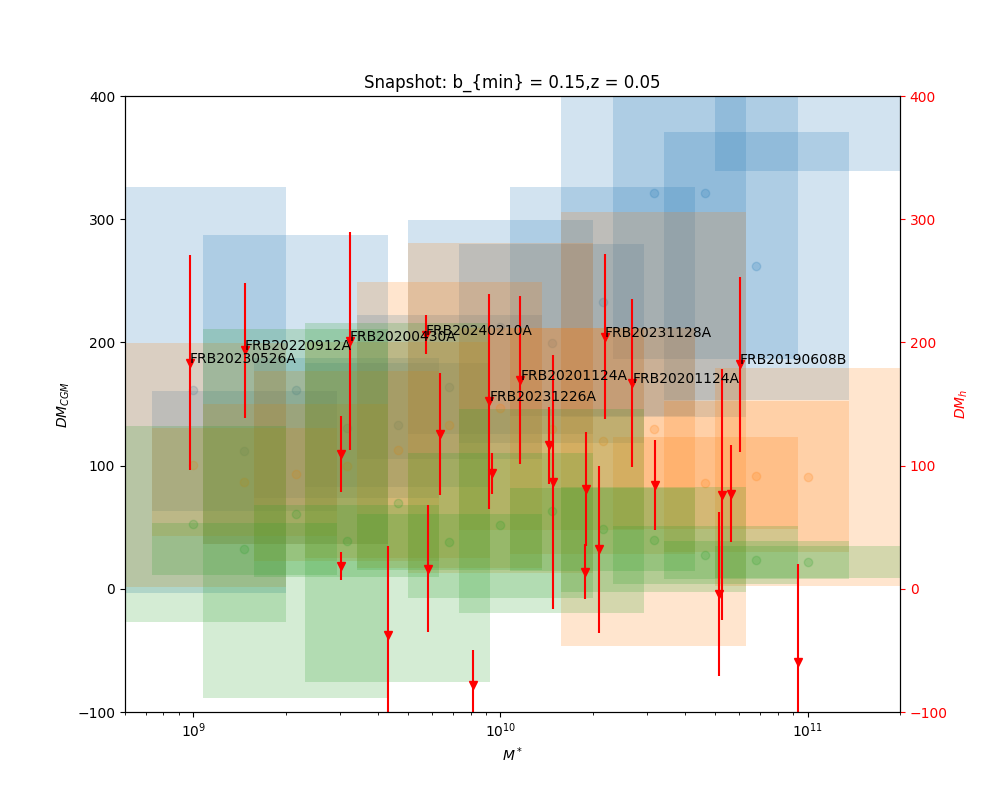

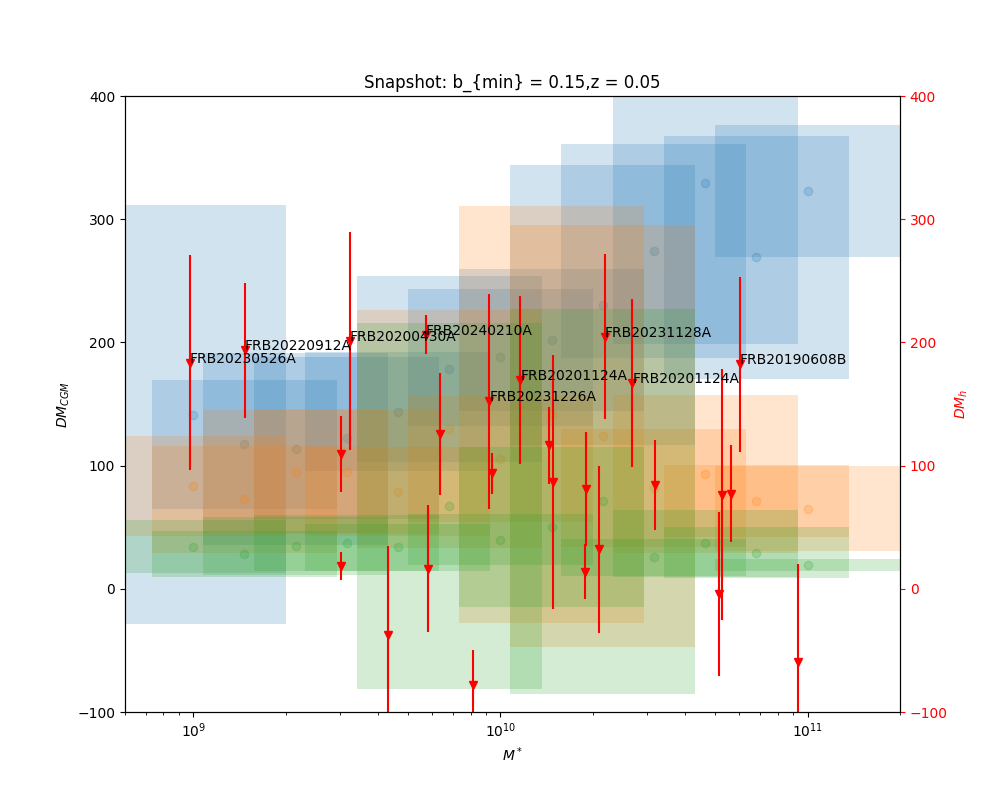

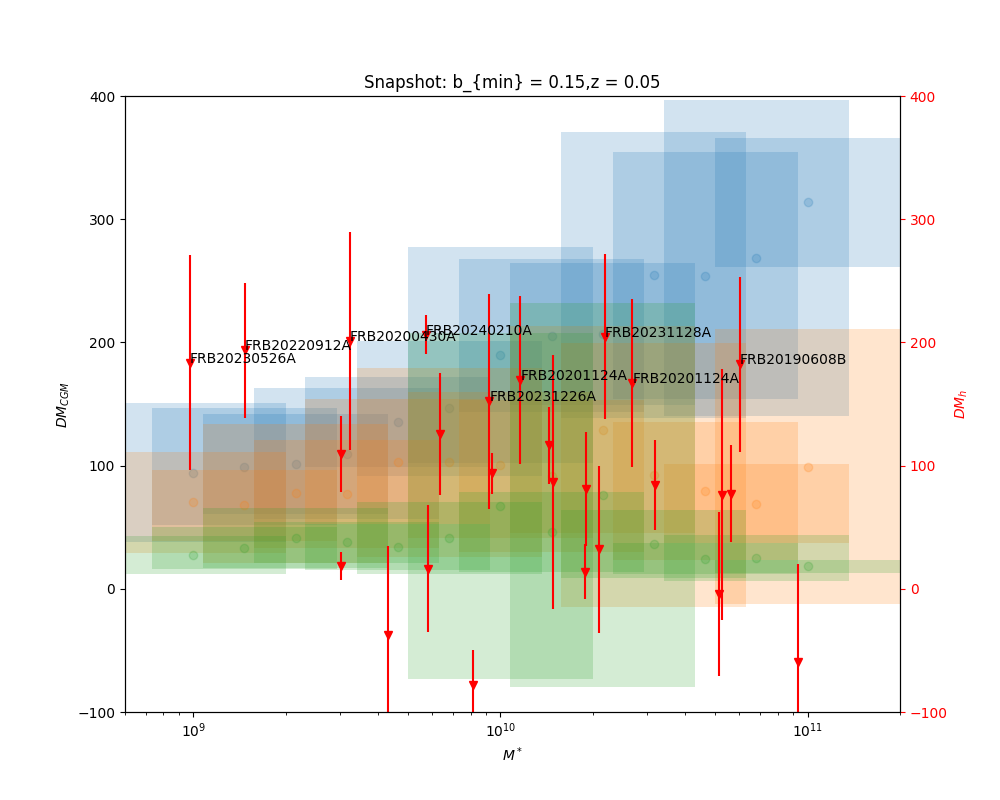

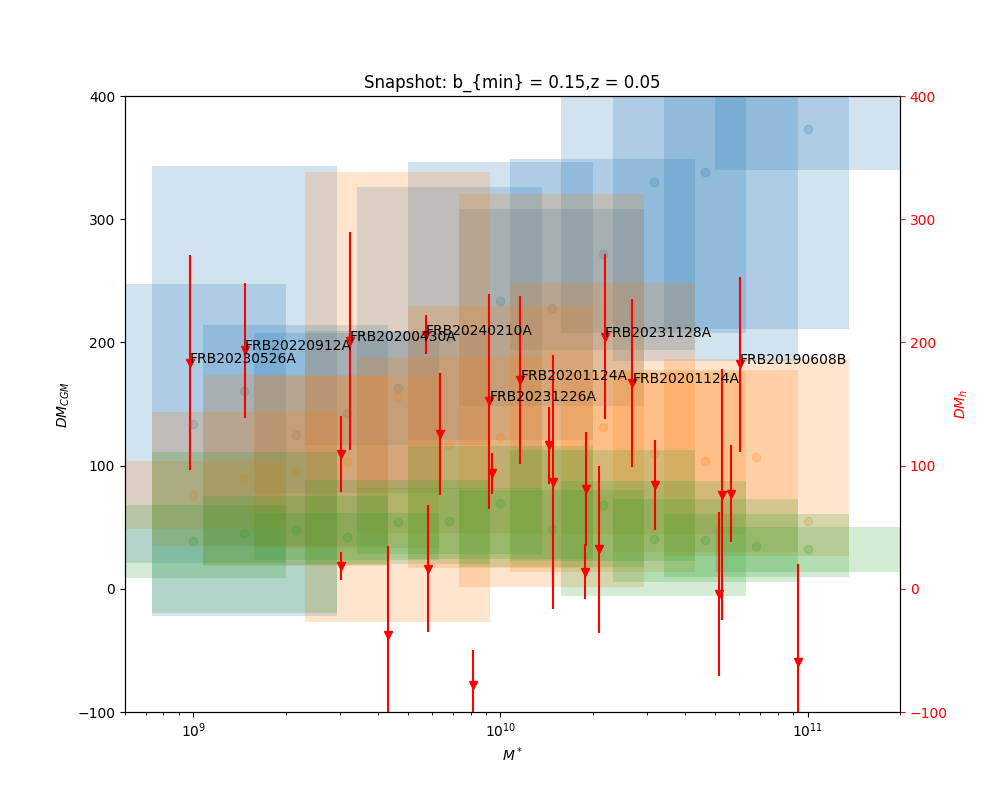

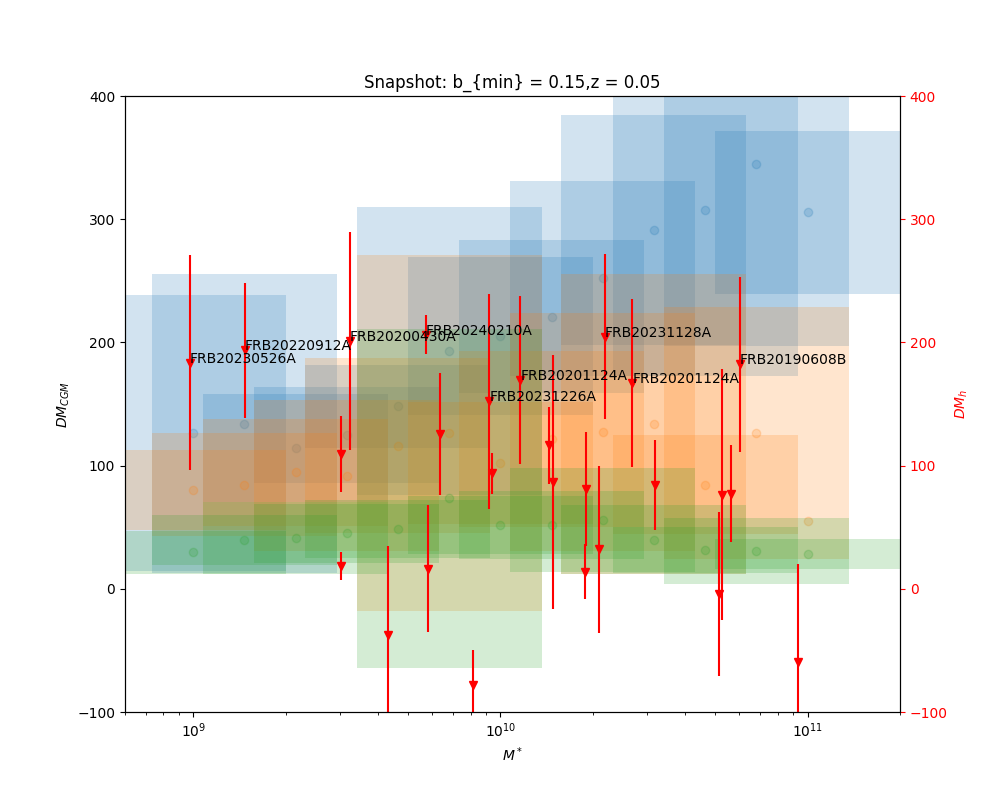

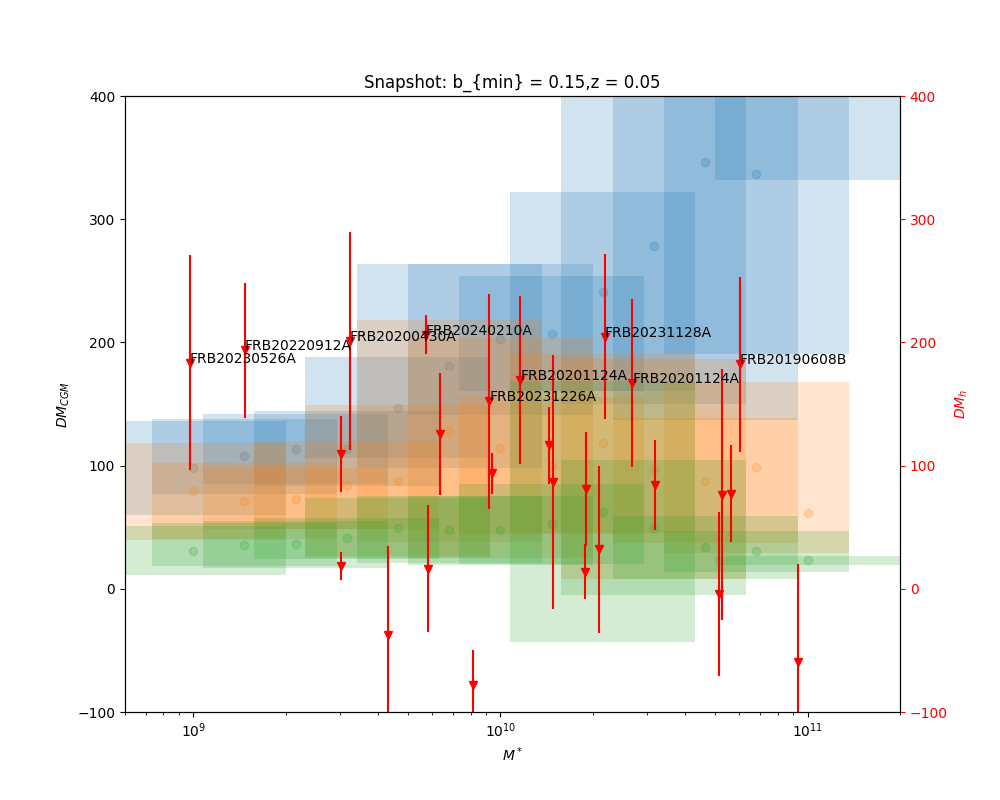

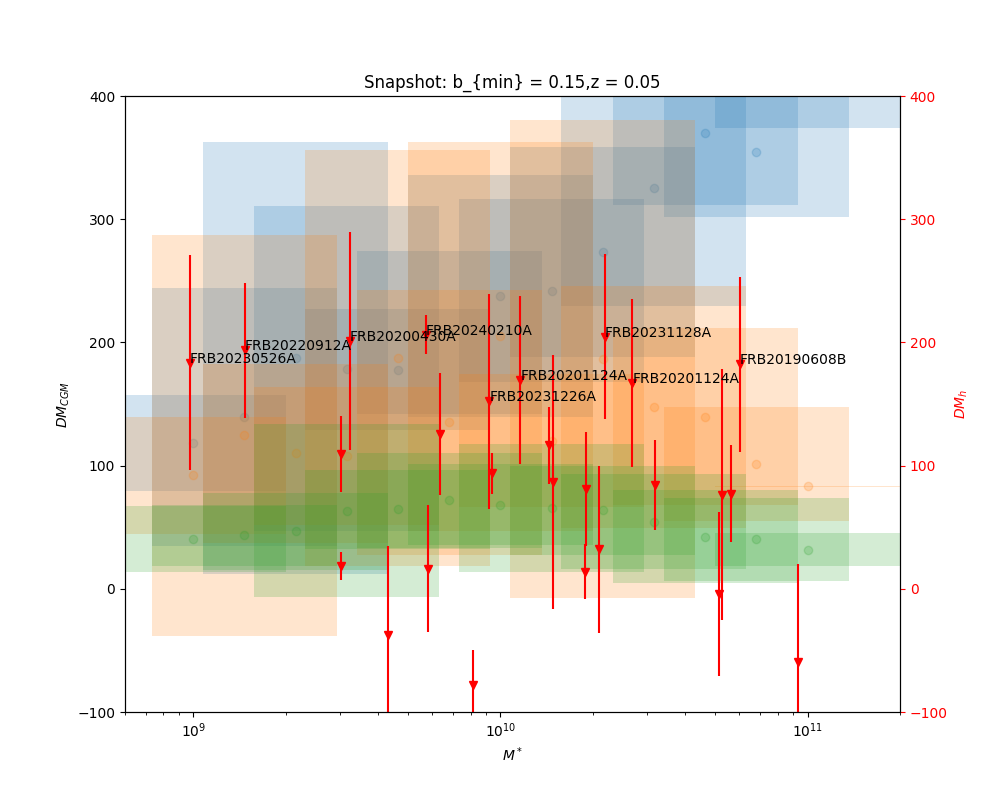

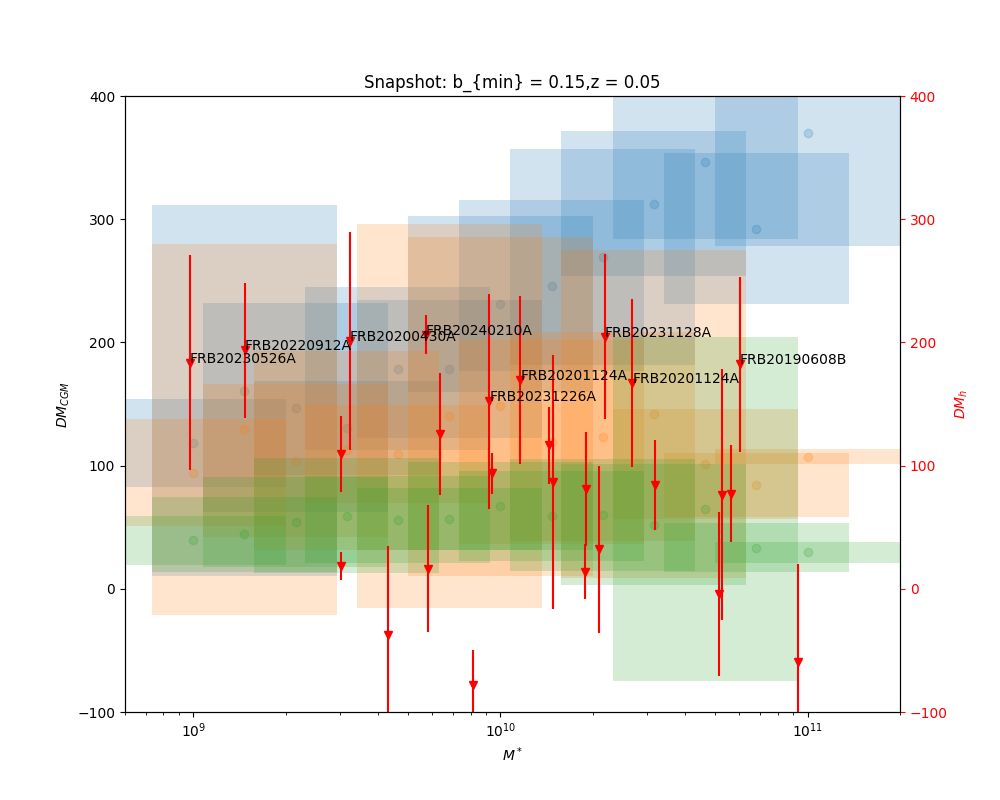

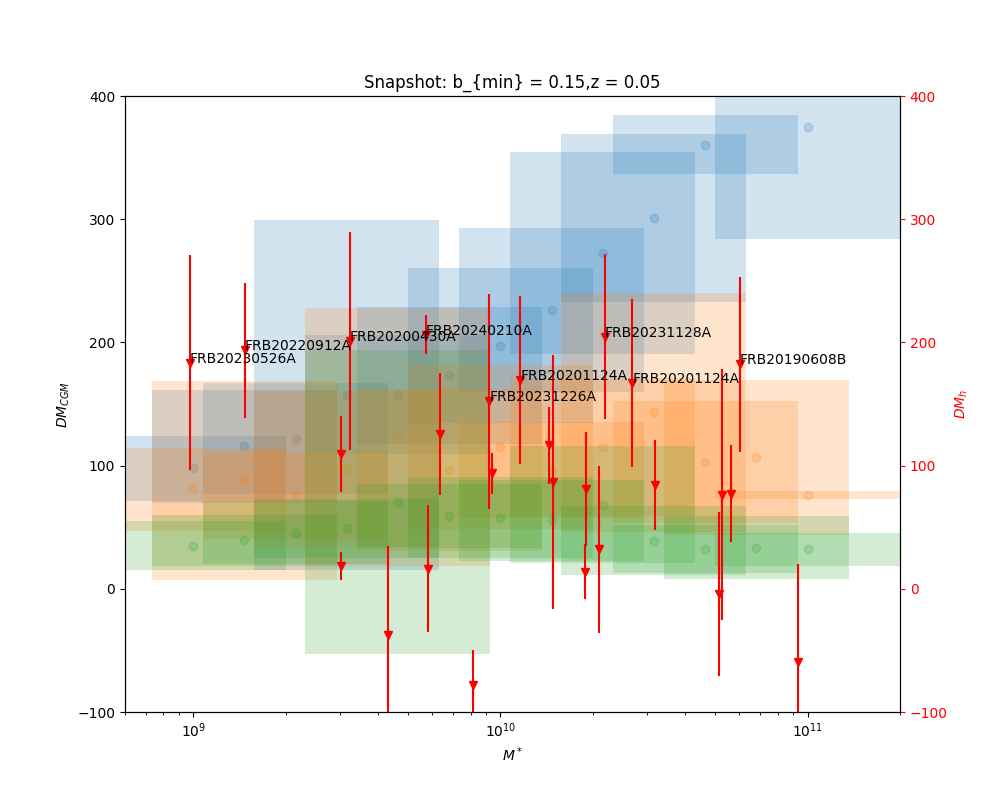

In [54]:
cm.inferno(np.linspace(0, 0.5, 3))
for snap_id in ['090','086','082']:
    for bb in [0.1,0.12,0.15]:
        plt.figure(figsize = (10,8))
        camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/Astrid_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C0')
        camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/IllustrisTNG_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C1')
        camels_tools.plot_theory_predictions(f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/SIMBA_1P_3_0_snap{snap_id}_haloDM_b={bb:.2f}.h5',
                        ax = plt.gca(),alpha = 0.2,facecolor = 'C2')


        plot_mstar = 10**dmh_tools.best_stellar_mass(df)
        plot_dm = df['DM_host_restframe']
        plt.errorbar(x = plot_mstar,y = df['DM_host_restframe'],yerr = dmh_tools.sigma_tot(df), linestyle = 'none',marker = 'v',color = 'red')
        
        plt.xscale('log')
        plt.xlim(6e8,2e11)
        plt.ylim(-100,400)
        plt.xlabel(r'$M^*$')
        plt.ylabel(r'$DM_{CGM}$',color = 'black')
        
        ax2 = plt.gca().twinx()
        ax2.set_ylabel(r'$DM_h$',color = 'red')
        ax2.tick_params(axis='y', colors='red')
        ax2.set_ylim(-100,400)
        plt.title('Snapshot: b_{min} = 0.15,z = 0.05')
        
        for ii, ms, dm in zip(np.arange(plot_mstar.size),plot_mstar,plot_dm):
            if dm > 150:
                plt.text(ms,dm,s = df.index[ii])

In [23]:
import matplotlib.pyplot as plt

In [24]:
from matplotlib import patches

255_374_548_783_803_501_310_196
219_322_450_668_709_439_274_173
155_213_314_471_499_299_179_119
467_725_830_859_857_812_543_184
416_652_706_673_707_706_468_161
239_400_460_484_519_492_314_102
518_561_749_803_674_849_746_329
401_440_658_718_570_717_648_290
335_362_438_465_412_516_446_195
385_491_644_848_818_483_254_133
338_426_505_702_707_406_211_108
195_249_362_492_490_296_146_77
508_741_805_881_915_801_434_46
Not enough halos after filtering. Found 39, but requested 40.
Not enough halos! 39 < 40, falling back on sampling WITH replacement (unphysical)
455_663_678_700_769_695_363_39
Not enough halos after filtering. Found 25, but requested 40.
Not enough halos! 25 < 40, falling back on sampling WITH replacement (unphysical)
271_403_450_510_557_465_237_25
556_614_800_812_804_881_689_252
461_517_715_709_654_745_591_211
365_367_435_443_475_522_408_153
444_573_707_904_853_535_235_109
412_514_579_774_762_466_206_96
238_314_423_553_510_312_138_64
596_815_787_917_1001_764_390_48
544_714_641_74

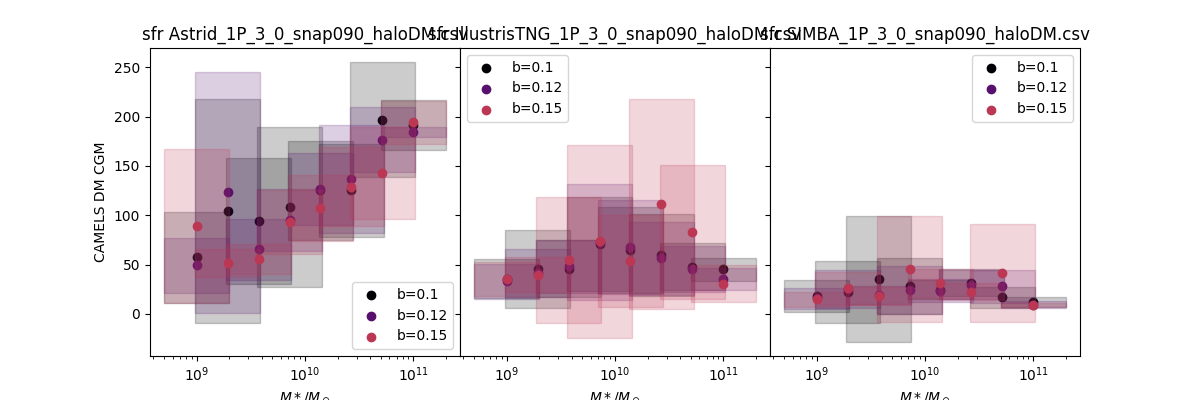

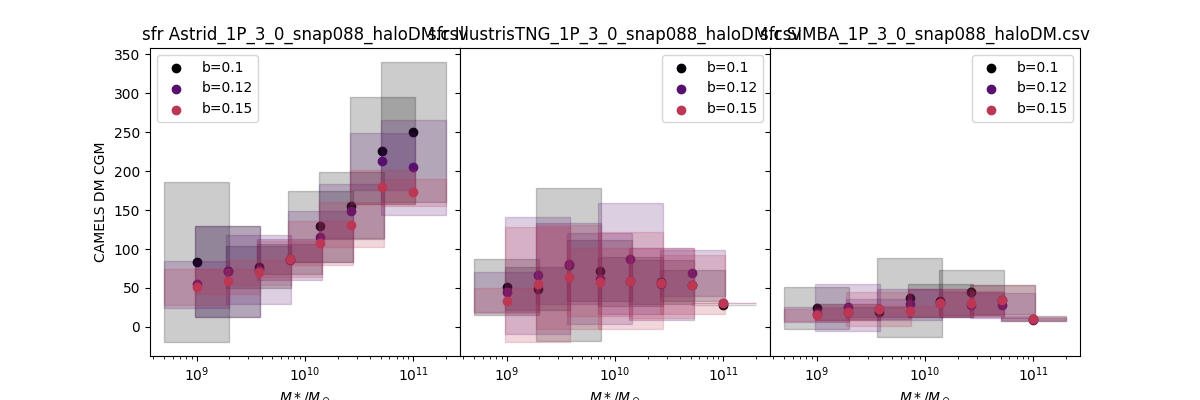

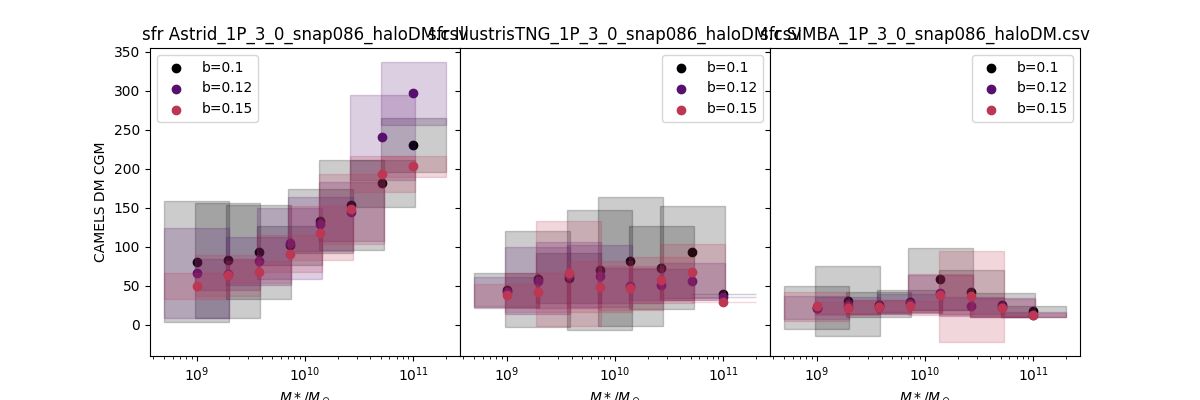

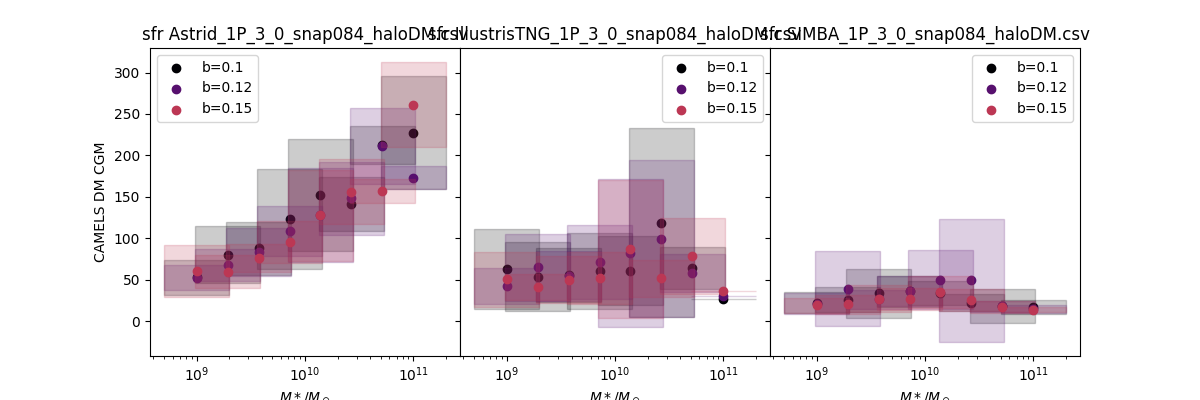

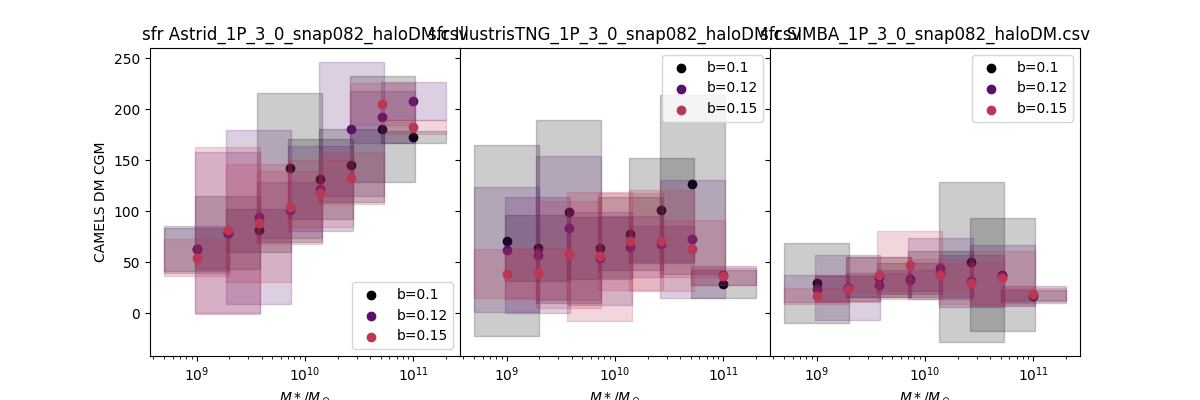

In [310]:

for nnn in ['090','088','086','084','082']:
    filepaths = glob(os.path.join(root_path,'data_products','camels_data','20250414',f'*snap{nnn}_haloDM.csv'))
    filepaths.sort()
    f,axs=plt.subplots(1,3,sharex=True,sharey=True,figsize = (12,4))
    axs[0].set_ylabel('CAMELS DM CGM')
    for filepath,ax in zip(filepaths,axs):
        num_halos = 40
        M_200_min = 0
        M_200_max = np.inf
        sfr_min = 0.1
        sfr_max = 100.0
    
        M_star_cen = np.geomspace(1e9,1e11,num = 8)
        all_results_all_b = []
        ax.set_xlabel(r'$M*/M_\odot$')
        ax.set_xscale('log')
        ax.set_yscale('linear')
        all_bmin = [0.1,0.12,0.15]
        for b_min,color in zip(all_bmin,cm.inferno(np.linspace(0, 0.5, len(all_bmin)))):
            for weighting in ['sfr']:
        
                all_results_this_b = []
                for M_star in M_star_cen:
                    M_star_min = M_star * 10**-0.3
                    M_star_max = M_star * 10**0.3
                    df, results, sampled_data = analyze_halos(
                        filepath=filepath,
                        num_halos=num_halos,
                        weighting = weighting,
                        b_min=b_min,
                        b_max=b_max,
                        M_200_min=M_200_min,
                        M_200_max=M_200_max,
                        M_star_min=M_star_min,
                        M_star_max=M_star_max,
                        sfr_min=sfr_min,
                        sfr_max=sfr_max
                    )
                    
                    #visualize_results(results, sampled_data)
                    #print(f'(N = {len(sampled_data)})','weighted-->',results['weighted_mean'],'+-',results['weighted_std'],'unweighted-->',results['unweighted_mean'],'+-',results['unweighted_std'])
                    all_results_this_b.append(results)
                plot_theory_predictions(all_results_this_b,ax,x_axis = 'M_star',weight = 'weighted',alpha = 0.2,label = f'b={b_min}',color = color)
                np.savez(os.path.join(root_path,'data_products','camels_stack',os.path.split(filepath)[-1][:-4] + '.npz'),
                      all_results=all_results_this_b
                )
                ax.set_title(weighting + ' ' + os.path.split(filepath)[-1])
                ax.legend()
        f.subplots_adjust(wspace=0)

In [ ]:
%matplotlib ipympl